<a href="https://colab.research.google.com/github/aniolarolas/quant-research-pricing-credit-risk/blob/main/04_fico_score_bucketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4: FICO Score Bucketing and Credit Rating Mapping

## 1. Problem Understanding

The objective of this task is to create a rating map that converts FICO scores into a smaller number of credit rating buckets.

A FICO score is a numerical credit score that summarizes the creditworthiness of a borrower. However, the model architecture described in the task requires categorical inputs, so the continuous FICO score must be transformed into discrete buckets.

The final output should be a function that maps a borrower's FICO score to a rating, where a lower rating represents a better credit score and lower credit risk.

This task can be interpreted as a quantization problem: a large set of possible FICO score values is compressed into a smaller number of discrete categories. The challenge is to choose bucket boundaries that summarize the relationship between FICO score and probability of default as well as possible.

## 2. Financial Background

Credit scores are commonly used as indicators of borrower creditworthiness. A higher FICO score generally indicates lower credit risk, while a lower FICO score indicates higher credit risk.

In credit risk modelling, converting a numerical score into rating buckets can make the model more interpretable and easier to use in downstream decision systems. Instead of treating every FICO score as a separate value, borrowers are grouped into rating categories with similar default behaviour.

For each bucket, the empirical probability of default can be estimated as:

$$
p_i = \frac{k_i}{n_i}
$$

where:

- $n_i$ is the number of borrowers in bucket $i$,
- $k_i$ is the number of defaults in bucket $i$,
- $p_i$ is the empirical default rate of bucket $i$.

A good bucketing method should create groups that are meaningful from a credit risk perspective: borrowers in the same bucket should have similar default risk, and lower FICO buckets should generally correspond to higher default rates.

## 3. Quantization Approach

There are several possible ways to map FICO scores into rating buckets.

A simple approach is to create buckets with approximately the same number of borrowers. This is easy to implement and provides a useful baseline, but it does not directly optimize default risk separation.

A more risk-oriented approach is to choose the bucket boundaries by maximizing the log-likelihood of the observed default outcomes. In this setup, each bucket has its own estimated probability of default:

$$
p_i = \frac{k_i}{n_i}
$$

and the contribution of each bucket to the log-likelihood is:

$$
LL_i =
k_i \log(p_i)
+
(n_i - k_i)\log(1 - p_i)
$$

The total objective is:

$$
LL =
\sum_i
\left[
k_i \log(p_i)
+
(n_i - k_i)\log(1 - p_i)
\right]
$$

The goal is to find the FICO score boundaries that maximize this objective.

This notebook will therefore compare:

1. a baseline quantile bucketing method,
2. an optimized bucketing method based on maximum log-likelihood.

## 4. Data Loading

We load the same loan dataset used in the previous credit risk task. For this task, the relevant variables are:

- `fico_score`: the numerical credit score of the borrower,
- `default`: the binary indicator showing whether the borrower defaulted.

The objective is to use these two variables to construct rating buckets based on the relationship between FICO score and observed default behaviour.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv("/content/drive/MyDrive/quant_research_jpm_jobsim/data/raw/Task 3 and 4_Loan_Data.csv")

Basic inspection of dataset

In [3]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df[["fico_score", "default"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   fico_score  10000 non-null  int64
 1   default     10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB


In [5]:
df[["fico_score", "default"]].describe()

,fico_score,default
count,10000.000000,10000.000000
mean,637.557700,0.185100
std,60.657906,0.388398
min,408.000000,0.000000
25%,597.000000,0.000000
50%,638.000000,0.000000
75%,679.000000,0.000000
max,850.000000,1.000000


In [6]:
df[["fico_score", "default"]].isnull().sum()

,0
fico_score,0
default,0


In [7]:
print("Minimum FICO score:", df["fico_score"].min())
print("Maximum FICO score:", df["fico_score"].max())
print("Number of unique FICO scores:", df["fico_score"].nunique())

Minimum FICO score: 408
Maximum FICO score: 850
Number of unique FICO scores: 374


The dataset contains numerical FICO scores and observed default outcomes. Since there are many possible FICO score values, the score will be discretized into a smaller number of rating buckets. The default indicator will be used to evaluate whether the buckets separate borrowers by credit risk.

## 5. FICO Score Exploration

Before creating rating buckets, we explore the distribution of FICO scores and their relationship with default outcomes.

This step helps verify whether lower FICO scores are associated with higher observed default rates, which is the expected credit risk pattern.

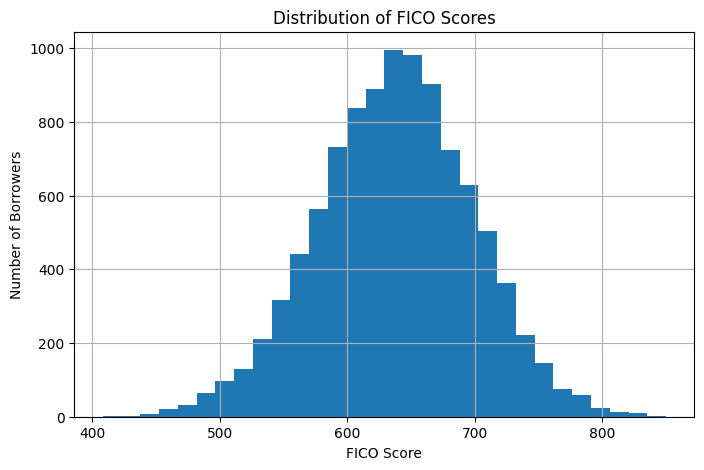

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["fico_score"], bins=30)

plt.xlabel("FICO Score")
plt.ylabel("Number of Borrowers")
plt.title("Distribution of FICO Scores")
plt.grid(True)
plt.show()

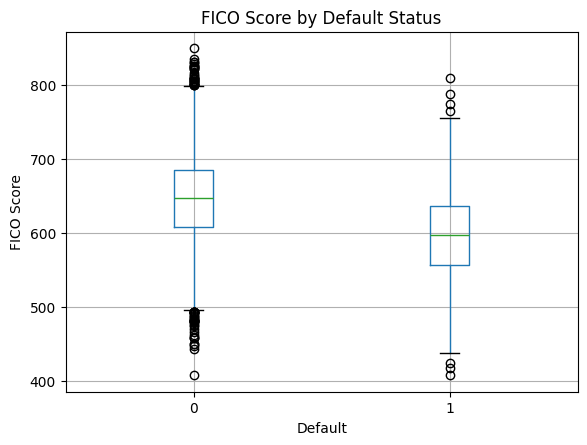

In [9]:
df.boxplot(column="fico_score", by="default")

plt.title("FICO Score by Default Status")
plt.suptitle("")
plt.xlabel("Default")
plt.ylabel("FICO Score")
plt.show()

In [10]:
df.groupby("default")["fico_score"].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,8149.0,646.938765,57.015049,408.0,609.0,647.0,685.0,850.0
1,1851.0,596.257699,58.949929,409.0,557.0,597.0,636.5,810.0


The distribution of FICO scores provides an initial view of the range and concentration of borrower credit scores.

The comparison by default status helps assess whether borrowers who defaulted tend to have lower FICO scores than borrowers who did not default. This relationship is important because the rating buckets should preserve the credit risk information contained in the FICO score.

In [11]:
fico_bins = pd.interval_range(
    start=df["fico_score"].min(),
    end=df["fico_score"].max(),
    periods=10
)

df["fico_range"] = pd.cut(df["fico_score"], bins=fico_bins)

fico_range_summary = (
    df.groupby("fico_range", observed=True)
    .agg(
        borrowers=("default", "count"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
        min_fico=("fico_score", "min"),
        max_fico=("fico_score", "max")
    )
    .reset_index()
)

fico_range_summary

,fico_range,borrowers,defaults,default_rate,min_fico,max_fico
0,"(408.0, 452.2]",11,7,0.636364,409,450
1,"(452.2, 496.4]",117,86,0.735043,455,496
2,"(496.4, 540.6]",439,224,0.510251,497,540
3,"(540.6, 584.8]",1323,468,0.353741,541,584
4,"(584.8, 629.0]",2529,518,0.204824,585,629
5,"(629.0, 673.2]",2807,372,0.132526,630,673
6,"(673.2, 717.4000000000001]",1856,146,0.078664,674,717
7,"(717.4000000000001, 761.6]",732,26,0.035519,718,761
8,"(761.6, 805.8]",161,3,0.018634,762,805
9,"(805.8, 850.0]",24,1,0.041667,806,850


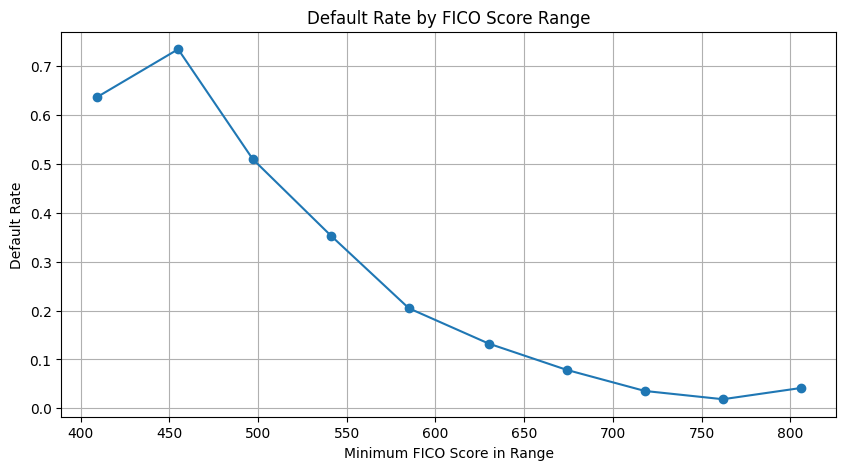

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    fico_range_summary["min_fico"],
    fico_range_summary["default_rate"],
    marker="o"
)

plt.xlabel("Minimum FICO Score in Range")
plt.ylabel("Default Rate")
plt.title("Default Rate by FICO Score Range")
plt.grid(True)
plt.show()

The exploratory FICO ranges show how the observed default rate changes across the credit score distribution. A valid rating map should generally assign better ratings to higher FICO scores and worse ratings to lower FICO scores.

## 6. Baseline Quantile Bucketing

As a simple baseline, we first create FICO score buckets using quantiles.

This approach assigns approximately the same number of borrowers to each bucket. It is easy to implement and provides a useful benchmark before applying a more optimized maximum likelihood approach.

Since higher FICO scores represent lower credit risk, the best ratings should correspond to the highest FICO score buckets.

In [13]:
NUM_BUCKETS = 10

df["quantile_bucket"] = pd.qcut(
    df["fico_score"],
    q=NUM_BUCKETS,
    labels=False,
    duplicates="drop"
)

In [14]:
max_bucket = df["quantile_bucket"].max()

df["quantile_rating"] = max_bucket - df["quantile_bucket"] + 1

In [15]:
quantile_summary = (
    df.groupby("quantile_rating")
    .agg(
        borrowers=("default", "count"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
        min_fico=("fico_score", "min"),
        max_fico=("fico_score", "max")
    )
    .reset_index()
    .sort_values("quantile_rating")
)

quantile_summary

,quantile_rating,borrowers,defaults,default_rate,min_fico,max_fico
0,1,988,36,0.036437,715,850
1,2,1005,72,0.071642,689,714
2,3,970,92,0.094845,671,688
3,4,1027,108,0.105161,654,670
4,5,997,128,0.128385,639,653
5,6,992,173,0.174395,624,638
6,7,984,179,0.181911,608,623
7,8,987,246,0.249240,588,607
8,9,1033,318,0.307841,561,587
9,10,1017,499,0.490659,408,560


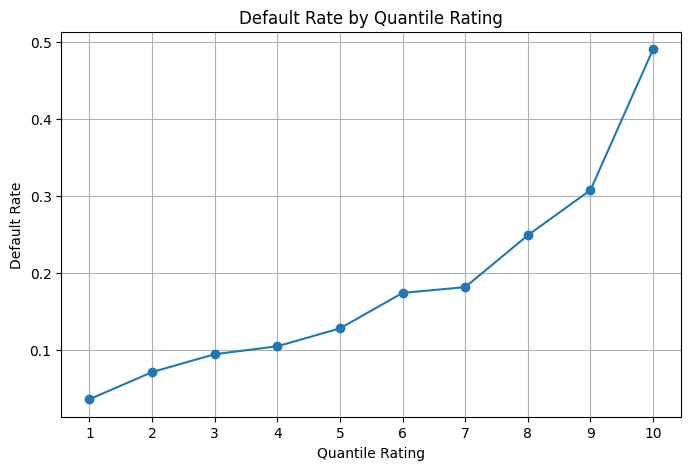

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    quantile_summary["quantile_rating"],
    quantile_summary["default_rate"],
    marker="o"
)

plt.xlabel("Quantile Rating")
plt.ylabel("Default Rate")
plt.title("Default Rate by Quantile Rating")
plt.xticks(quantile_summary["quantile_rating"])
plt.grid(True)
plt.show()

The quantile bucketing baseline creates rating groups with approximately the same number of borrowers. This makes the buckets balanced in terms of sample size, but the bucket boundaries are not chosen to directly maximize separation in default behaviour.

The default rate by rating provides a first check of whether the rating system is directionally sensible. Since rating 1 corresponds to the highest FICO scores, default rates should generally increase as the rating number increases.

Although quantile bucketing is simple and interpretable, it does not explicitly optimize the likelihood of the observed default outcomes. The next section improves on this by selecting bucket boundaries using a maximum likelihood objective.

## 7. Maximum Likelihood Bucketing

The quantile approach creates balanced buckets, but it does not directly optimize how well the buckets explain the observed default outcomes.

We now build an optimized bucketing method based on maximum log-likelihood.

The idea is to sort borrowers by FICO score and find contiguous FICO score intervals. For each interval, we estimate the probability of default using the empirical default rate in that bucket.

For a bucket $i$, let:

- $n_i$ be the number of borrowers in the bucket,
- $k_i$ be the number of defaults in the bucket,
- $p_i$ be the estimated probability of default in the bucket.

The estimated probability of default is:

$$
p_i = \frac{k_i}{n_i}
$$

The bucket log-likelihood is:

$$
LL_i =
k_i \log(p_i)
+
(n_i - k_i)\log(1 - p_i)
$$

The total log-likelihood across all buckets is:

$$
LL =
\sum_{i=1}^{B}
\left[
k_i \log(p_i)
+
(n_i - k_i)\log(1 - p_i)
\right]
$$

where $B$ is the total number of buckets.

The objective is to choose the FICO score bucket boundaries that maximize the total log-likelihood.

To avoid very small and unstable buckets, we also impose a minimum number of borrowers per bucket.

In [17]:
fico_data = (
    df.groupby("fico_score")
    .agg(
        borrowers=("default", "count"),
        defaults=("default", "sum")
    )
    .reset_index()
    .sort_values("fico_score")
    .reset_index(drop=True)
)

fico_data.head()

,fico_score,borrowers,defaults
0,408,1,0
1,409,1,1
2,418,1,1
3,425,1,1
4,438,1,1


In [18]:
fico_scores = fico_data["fico_score"].values
borrower_counts = fico_data["borrowers"].values
default_counts = fico_data["defaults"].values

prefix_borrowers = np.concatenate([[0], np.cumsum(borrower_counts)])
prefix_defaults = np.concatenate([[0], np.cumsum(default_counts)])

num_unique_scores = len(fico_scores)

print("Number of unique FICO scores:", num_unique_scores)

Number of unique FICO scores: 374


In [19]:
def bucket_log_likelihood(start_idx, end_idx):

    # Computes the binomial log-likelihood for one FICO bucket.

    # The bucket includes FICO score indices from start_idx to end_idx, inclusive.

    n = prefix_borrowers[end_idx + 1] - prefix_borrowers[start_idx]
    k = prefix_defaults[end_idx + 1] - prefix_defaults[start_idx]

    if n == 0:
        return -np.inf

    p = k / n

    epsilon = 1e-12
    p = np.clip(p, epsilon, 1 - epsilon)

    log_likelihood = k * np.log(p) + (n - k) * np.log(1 - p)

    return log_likelihood

In [20]:
NUM_BUCKETS = 10
MIN_BUCKET_SIZE = 100

dp = np.full((NUM_BUCKETS + 1, num_unique_scores), -np.inf)
split_points = np.full((NUM_BUCKETS + 1, num_unique_scores), -1)

# Base case: one bucket from the first FICO score to score j
for j in range(num_unique_scores):
    n = prefix_borrowers[j + 1] - prefix_borrowers[0]

    if n >= MIN_BUCKET_SIZE:
        dp[1, j] = bucket_log_likelihood(0, j)

# Dynamic programming recursion
for b in range(2, NUM_BUCKETS + 1):
    for j in range(num_unique_scores):
        for split in range(b - 2, j):
            previous_n = prefix_borrowers[split + 1] - prefix_borrowers[0]
            current_n = prefix_borrowers[j + 1] - prefix_borrowers[split + 1]

            if previous_n < (b - 1) * MIN_BUCKET_SIZE:
                continue

            if current_n < MIN_BUCKET_SIZE:
                continue

            candidate_ll = dp[b - 1, split] + bucket_log_likelihood(split + 1, j)

            if candidate_ll > dp[b, j]:
                dp[b, j] = candidate_ll
                split_points[b, j] = split

In [23]:
def reconstruct_buckets(split_points, num_buckets, last_index):
    buckets = []
    current_end = int(last_index)

    for b in range(num_buckets, 0, -1):
        split = int(split_points[b, current_end])

        if b == 1:
            current_start = 0
        else:
            current_start = split + 1

        buckets.append((int(current_start), int(current_end)))
        current_end = split

    buckets.reverse()
    return buckets


optimal_bucket_indices = reconstruct_buckets(
    split_points=split_points,
    num_buckets=NUM_BUCKETS,
    last_index=num_unique_scores - 1
)

In [24]:
optimal_buckets = []

for bucket_number, (start_idx, end_idx) in enumerate(optimal_bucket_indices, start=1):
    min_fico = fico_scores[start_idx]
    max_fico = fico_scores[end_idx]

    n = prefix_borrowers[end_idx + 1] - prefix_borrowers[start_idx]
    k = prefix_defaults[end_idx + 1] - prefix_defaults[start_idx]
    default_rate = k / n

    optimal_buckets.append({
        "bucket_number_low_to_high_fico": bucket_number,
        "min_fico": min_fico,
        "max_fico": max_fico,
        "borrowers": n,
        "defaults": k,
        "default_rate": default_rate
    })

optimal_buckets_df = pd.DataFrame(optimal_buckets)

optimal_buckets_df


,bucket_number_low_to_high_fico,min_fico,max_fico,borrowers,defaults,default_rate
0,1,408,502,168,121,0.720238
1,2,503,520,133,78,0.586466
2,3,521,552,496,229,0.461694
3,4,553,580,911,307,0.336992
4,5,581,611,1561,381,0.244074
5,6,612,649,2465,402,0.163083
6,7,650,696,2609,256,0.098122
7,8,697,732,1104,64,0.057971
8,9,733,739,122,0,0.000000
9,10,740,850,431,13,0.030162


In [25]:
optimal_buckets_df["rating"] = (
    NUM_BUCKETS - optimal_buckets_df["bucket_number_low_to_high_fico"] + 1
)

optimal_buckets_df = optimal_buckets_df.sort_values("rating").reset_index(drop=True)

optimal_buckets_df

,bucket_number_low_to_high_fico,min_fico,max_fico,borrowers,defaults,default_rate,rating
0,10,740,850,431,13,0.030162,1
1,9,733,739,122,0,0.000000,2
2,8,697,732,1104,64,0.057971,3
3,7,650,696,2609,256,0.098122,4
4,6,612,649,2465,402,0.163083,5
5,5,581,611,1561,381,0.244074,6
6,4,553,580,911,307,0.336992,7
7,3,521,552,496,229,0.461694,8
8,2,503,520,133,78,0.586466,9
9,1,408,502,168,121,0.720238,10


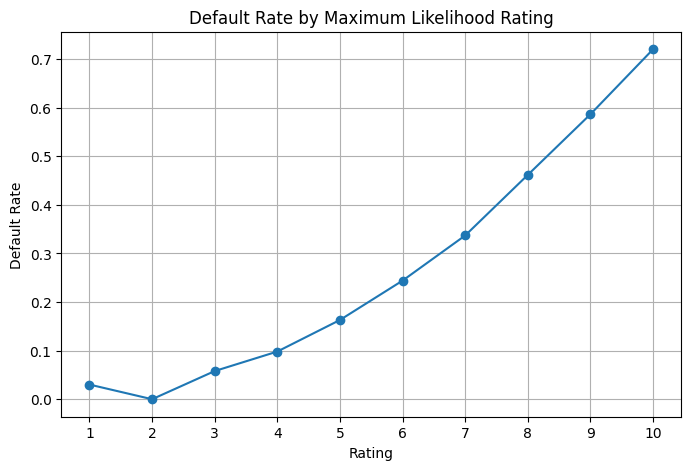

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    optimal_buckets_df["rating"],
    optimal_buckets_df["default_rate"],
    marker="o"
)

plt.xlabel("Rating")
plt.ylabel("Default Rate")
plt.title("Default Rate by Maximum Likelihood Rating")
plt.xticks(optimal_buckets_df["rating"])
plt.grid(True)
plt.show()

The optimized buckets are selected by maximizing the log-likelihood of the observed default outcomes. Unlike quantile bucketing, this method chooses boundaries based on how well each bucket explains default behaviour.

The resulting ratings should generally show increasing default rates as the rating number worsens. Rating 1 corresponds to the strongest FICO score range, while higher rating numbers correspond to weaker credit profiles.

## 8. Baseline vs Maximum Likelihood Comparison

We now compare the baseline quantile buckets with the optimized maximum likelihood buckets.

The quantile method creates balanced buckets with approximately the same number of borrowers, while the maximum likelihood method selects boundaries that better explain the observed default outcomes.

To compare both methods, we evaluate:

- bucket default rates,
- total log-likelihood,
- interpretability of the resulting rating map.

In [27]:
def total_log_likelihood_from_summary(summary_df):
    total_ll = 0.0
    epsilon = 1e-12

    for _, row in summary_df.iterrows():
        n = row["borrowers"]
        k = row["defaults"]

        p = k / n
        p = np.clip(p, epsilon, 1 - epsilon)

        bucket_ll = k * np.log(p) + (n - k) * np.log(1 - p)
        total_ll += bucket_ll

    return total_ll

In [28]:
quantile_log_likelihood = total_log_likelihood_from_summary(quantile_summary)
maximum_likelihood_log_likelihood = total_log_likelihood_from_summary(optimal_buckets_df)

comparison = pd.DataFrame({
    "method": ["Quantile Bucketing", "Maximum Likelihood Bucketing"],
    "total_log_likelihood": [
        quantile_log_likelihood,
        maximum_likelihood_log_likelihood
    ]
})

comparison

,method,total_log_likelihood
0,Quantile Bucketing,-4267.901399
1,Maximum Likelihood Bucketing,-4218.066373


A higher total log-likelihood indicates that the bucket structure explains the observed default outcomes better.

The maximum likelihood method is expected to achieve a higher log-likelihood because its boundaries are selected specifically to optimize this objective.

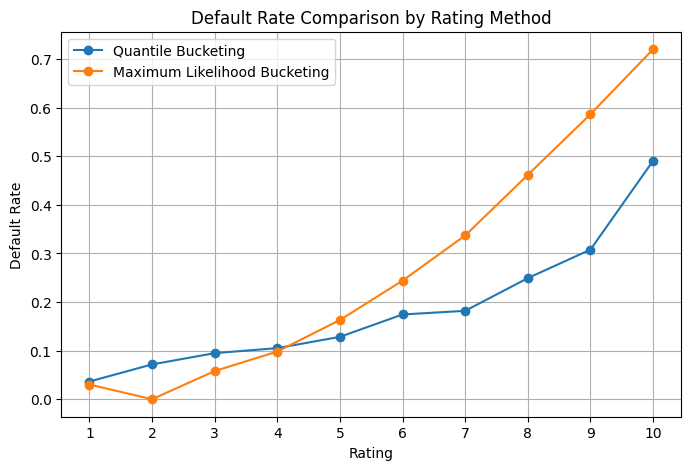

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    quantile_summary["quantile_rating"],
    quantile_summary["default_rate"],
    marker="o",
    label="Quantile Bucketing"
)

plt.plot(
    optimal_buckets_df["rating"],
    optimal_buckets_df["default_rate"],
    marker="o",
    label="Maximum Likelihood Bucketing"
)

plt.xlabel("Rating")
plt.ylabel("Default Rate")
plt.title("Default Rate Comparison by Rating Method")
plt.xticks(range(1, NUM_BUCKETS + 1))
plt.legend()
plt.grid(True)
plt.show()

In [30]:
optimal_default_rates = optimal_buckets_df.sort_values("rating")["default_rate"]

is_monotonic = optimal_default_rates.is_monotonic_increasing

print("Are default rates monotonically increasing by rating?", is_monotonic)

Are default rates monotonically increasing by rating? False


In [31]:
optimal_buckets_df[
    ["rating", "min_fico", "max_fico", "borrowers", "defaults", "default_rate"]
]

,rating,min_fico,max_fico,borrowers,defaults,default_rate
0,1,740,850,431,13,0.030162
1,2,733,739,122,0,0.000000
2,3,697,732,1104,64,0.057971
3,4,650,696,2609,256,0.098122
4,5,612,649,2465,402,0.163083
5,6,581,611,1561,381,0.244074
6,7,553,580,911,307,0.336992
7,8,521,552,496,229,0.461694
8,9,503,520,133,78,0.586466
9,10,408,502,168,121,0.720238


The comparison shows how the default rate changes across ratings for both methods.

The quantile method is simple and produces balanced bucket sizes, but it does not directly optimize default risk separation. The maximum likelihood method is more risk-oriented because it chooses bucket boundaries based on the observed default behaviour.

For the final rating map, we use the maximum likelihood buckets.

## 9. Final Rating Function

Using the maximum likelihood buckets selected above, we now define a function that maps any FICO score to its corresponding credit rating.

The function uses the final rating map, where:

- rating 1 corresponds to the strongest credit profile,
- higher ratings correspond to weaker credit profiles.

This makes the bucketing method usable for future borrower data.

In [32]:
rating_map = optimal_buckets_df[
    ["rating", "min_fico", "max_fico", "default_rate"]
].copy()

rating_map

,rating,min_fico,max_fico,default_rate
0,1,740,850,0.030162
1,2,733,739,0.000000
2,3,697,732,0.057971
3,4,650,696,0.098122
4,5,612,649,0.163083
5,6,581,611,0.244074
6,7,553,580,0.336992
7,8,521,552,0.461694
8,9,503,520,0.586466
9,10,408,502,0.720238


In [33]:
def get_fico_rating_details(fico_score, rating_map=rating_map):

    ## Maps a FICO score to a credit rating and returns the associated bucket information.

    for _, row in rating_map.iterrows():
        if row["min_fico"] <= fico_score <= row["max_fico"]:
            return {
                "fico_score": fico_score,
                "rating": int(row["rating"]),
                "bucket_min_fico": int(row["min_fico"]),
                "bucket_max_fico": int(row["max_fico"]),
                "bucket_default_rate": float(row["default_rate"])
            }

    if fico_score < rating_map["min_fico"].min():
        row = rating_map.loc[rating_map["min_fico"].idxmin()]
    elif fico_score > rating_map["max_fico"].max():
        row = rating_map.loc[rating_map["max_fico"].idxmax()]

    return {
        "fico_score": fico_score,
        "rating": int(row["rating"]),
        "bucket_min_fico": int(row["min_fico"]),
        "bucket_max_fico": int(row["max_fico"]),
        "bucket_default_rate": float(row["default_rate"])
    }

In [34]:
sample_fico_scores = [520, 580, 620, 660, 700, 740, 780, 820]

sample_ratings = pd.DataFrame([
    get_fico_rating_details(score)
    for score in sample_fico_scores
])

sample_ratings

,fico_score,rating,bucket_min_fico,bucket_max_fico,bucket_default_rate
0,520,9,503,520,0.586466
1,580,7,553,580,0.336992
2,620,5,612,649,0.163083
3,660,4,650,696,0.098122
4,700,3,697,732,0.057971
5,740,1,740,850,0.030162
6,780,1,740,850,0.030162
7,820,1,740,850,0.030162


The final function maps each FICO score to the optimized rating bucket selected by the maximum likelihood procedure.

The output includes both the assigned rating and the historical default rate of the corresponding bucket. This makes the rating system interpretable and suitable for use in future datasets that require categorical credit score inputs.

## 10. Apply Rating Map to the Dataset

We now apply the final FICO rating function to the full dataset.

This creates a new categorical rating variable that can be used in downstream models requiring categorical inputs.

In [39]:
df["fico_rating"] = df["fico_score"].apply(get_fico_rating_details)
df[["fico_score", "fico_rating", "default"]].head()

,fico_score,fico_rating,default
0,605,"{'fico_score': 605, 'rating': 6, 'bucket_min_f...",0
1,572,"{'fico_score': 572, 'rating': 7, 'bucket_min_f...",1
2,602,"{'fico_score': 602, 'rating': 6, 'bucket_min_f...",0
3,612,"{'fico_score': 612, 'rating': 5, 'bucket_min_f...",0
4,631,"{'fico_score': 631, 'rating': 5, 'bucket_min_f...",0


## 11. Limitations and Next Steps

This notebook builds a FICO score rating map using quantization and maximum likelihood optimization.

The final method converts a numerical FICO score into a categorical credit rating, where lower ratings represent stronger credit profiles and higher ratings represent weaker credit profiles.

Compared with simple quantile bucketing, the maximum likelihood approach is more directly aligned with the credit risk objective of the task because it chooses bucket boundaries based on observed default behaviour.

However, the method has several limitations. First, the rating map is based only on FICO score and does not include other borrower characteristics such as income, debt levels, employment history, or outstanding loan amounts. These variables may also contain important information about default risk.

Second, the optimized buckets are estimated using historical data. If borrower behaviour or economic conditions change, the relationship between FICO score and default risk may also change.

Third, some buckets may still be sensitive to sample size, especially if the minimum bucket size is set too low. In a production setting, the bucket structure should be validated on out-of-sample data and monitored over time.

Future improvements could include testing different numbers of buckets, using out-of-time validation, enforcing monotonic default rates explicitly, and combining FICO-based ratings with other borrower-level risk factors.

Overall, the maximum likelihood rating map provides a clear and interpretable way to transform FICO scores into categorical credit ratings for downstream credit risk models.